### Limpieza de Datos

In [2]:
#Librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Carga de datos crudos
data_raw = pd.read_csv("../data/raw/data.txt",sep=',')
#carga diccionario campos
diccionario_campos = pd.read_csv("../data/raw/dict_data.txt",sep='|')

In [4]:
#Vista previa datos
data_raw.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [5]:
#resumen del dataset
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [6]:
#Cantidad nulos.
data_raw.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

1. Se  observa que el valor que determina la contaminacion (pm2.5), cuenta con valores nulos, los cuales se eliminaran, ya que no representan más del 5% del dataset.


In [7]:
#dataframe Limpio sin NaN
data_clean = data_raw.dropna().copy()

#Al tener las colunmas de fechas separadas, es conveniente tenerla en una sola colunma de tipo datetime. Esto permite que el modelo entienda la continuidad del tiempo
# y la relación que hay entre los registros. 
data_clean['date'] = pd.to_datetime(data_clean[['year', 'month', 'day', 'hour']])

#Se eliman esas columnas: year, month, day, hour, y No que no es relevante
data_clean.drop(columns=['year','month','day','hour','No'], inplace=True)
data_clean.set_index('date', inplace=True) #Agrego la columna 'date' como mi indice principal
data_clean.head()  

,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
date,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0


In [8]:
#Para la variable 'cbwd' que mide la direccion del viento con valores categoricos, se convertiran a valores numericos aplicando un 
# label encoding (asignacion de numeros en orden alfabetico)
# Valores : SE, NW , NE

#propiedad de pandas para el label encoding
data_clean['cbwd'] = data_clean['cbwd'].astype('category').cat.codes

data_clean.head()


,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
date,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,2,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,2,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,2,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,2,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,2,6.25,2,0


In [ ]:
#Guardo mi dataset procesado y listo para pasarlo al modelo
data_clean.to_csv('../data/processed/data_clean.csv', index=True)

### EDA

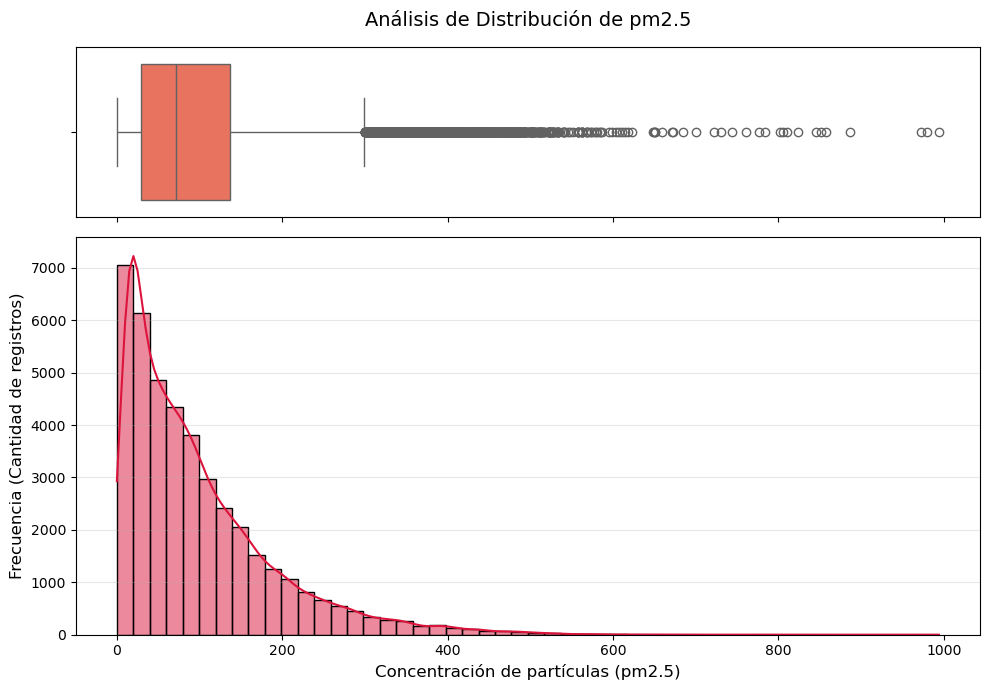

In [9]:
#Concentracion de la polucion usando histograma y diagrama de bigotes

fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": (0.3, 0.7)})

#Diagrama de Caja
sns.boxplot(x=data_clean['pm2.5'], ax=ax_box, color='tomato')
ax_box.set_title('Análisis de Distribución de pm2.5', fontsize=14, pad=15)
ax_box.set(xlabel='') #Borrar texto del eje X de arriba para que no se encime

# 3.Histograma con línea de densidad
sns.histplot(data_clean['pm2.5'], bins=50, kde=True, ax=ax_hist, color='crimson', edgecolor='black')
ax_hist.set_xlabel('Concentración de partículas (pm2.5)', fontsize=12)
ax_hist.set_ylabel('Frecuencia (Cantidad de registros)', fontsize=12)
ax_hist.grid(axis='y', alpha=0.3)

#Ajuste figura
plt.tight_layout()
plt.show()


En el diagrama de bigotes y en el histograma se observa que la mayor concentración de los datos se agrupa en los niveles normales de contaminación, específicamente entre 0 y 180 µg/m³. Por otro lado, el gráfico identifica una presencia significativa de valores atípicos (outliers) a partir de los 300 hasta alcanzar picos cercanos a 1,000 µg/m³. Estos registros representan episodios de contaminación severa y extrema en el conjunto de datos

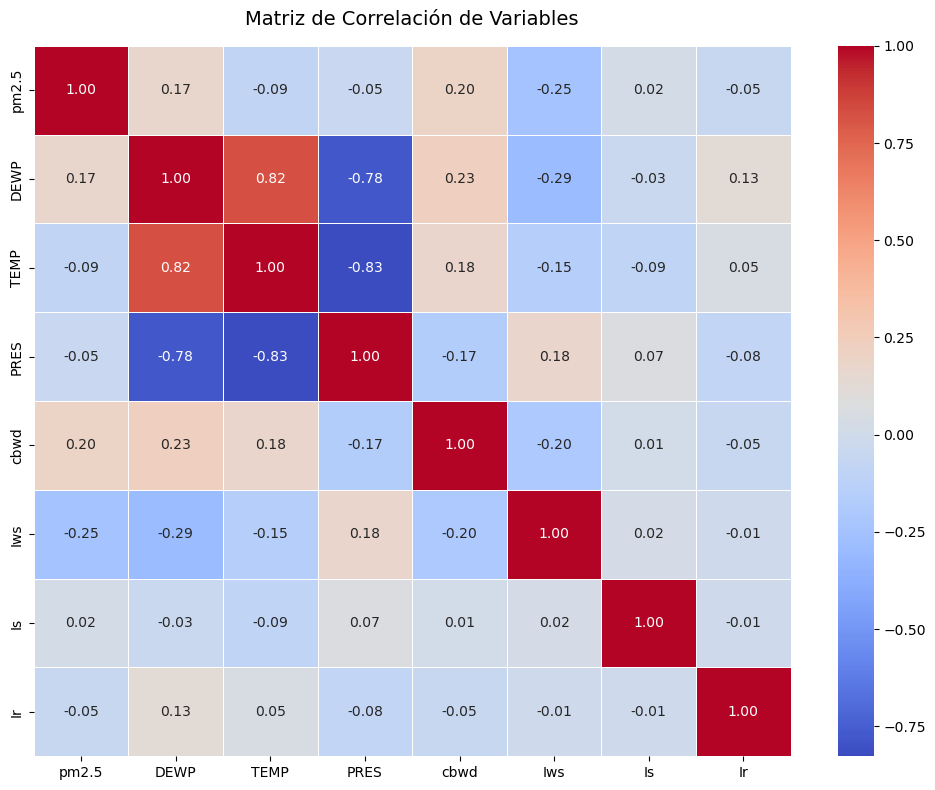

In [10]:
#Grafica de correlacion de variables

# Filtrar solo las columnas numéricas de tu dataset limpio
df_num = data_clean.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


Hallasgo de la correlacion pm2.5
1. Relación inversa con Iws: Al tener una  velocidad del viento (Iws) mayor, menor es la contaminación. (Correlacion -0.25)
2. Relacion directa con cbwd: Para algunas direcciones del viento (cbwd) puede implicar más contaminación en el area.  (Correlacion 0.20)
3. Relacion directa Dewp: El punto de rocío (Dewp) cuenta con una correlacion positiva de 0.17, lo que indica que a mayor humedad en el aire más contaminacion


C:\Users\alexa\AppData\Local\Temp\ipykernel_6688\1772848984.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_clean.index.month, y=data_clean['pm2.5'], palette='viridis', legend=False)


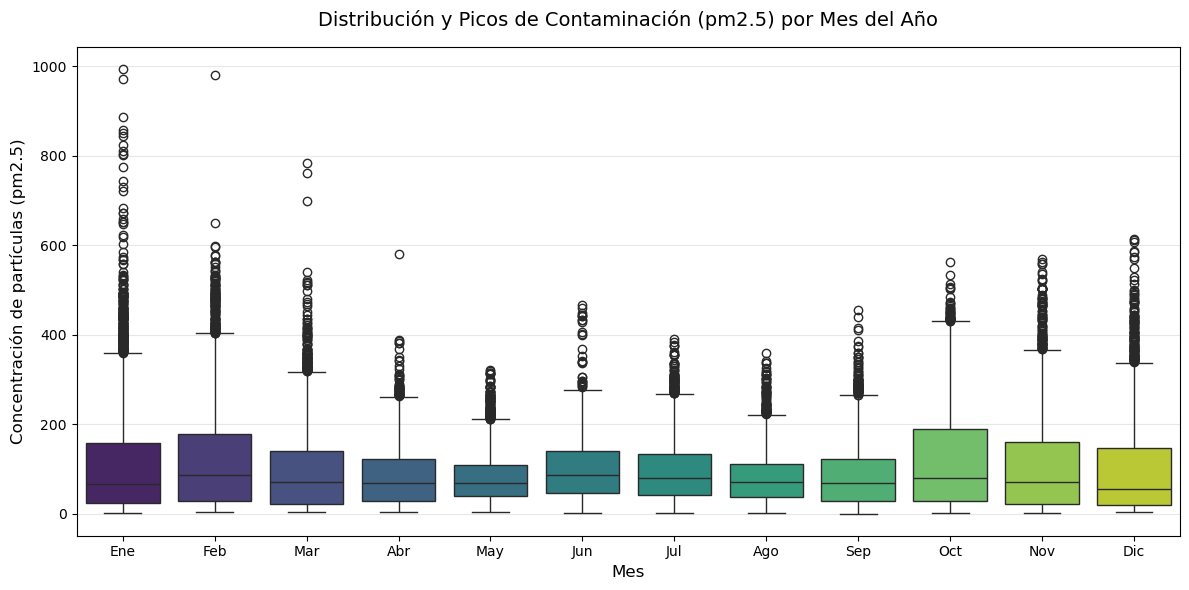

In [11]:
#Grafico de bigotes por meses del año 
plt.figure(figsize=(12, 6))

# Se agrupa los datos por el mes del índice y se grafica pm2.5
sns.boxplot(x=data_clean.index.month, y=data_clean['pm2.5'], palette='viridis', legend=False)

# configuracion etiquetas
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.xticks(ticks=range(0, 12), labels=meses)

plt.title('Distribución y Picos de Contaminación (pm2.5) por Mes del Año', fontsize=14, pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Concentración de partículas (pm2.5)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


La distribución por meses revela que los niveles más altos y los picos más críticos de pm2.5 se concentran entre enero y abril. A partir de mayo y hasta agosto el dataset muestra una tregua, con una reducción importante en la polución. Sin embargo, al llegar los meses finales del año, la tendencia se revierte y la contaminación vuelve a subir de forma sostenida.

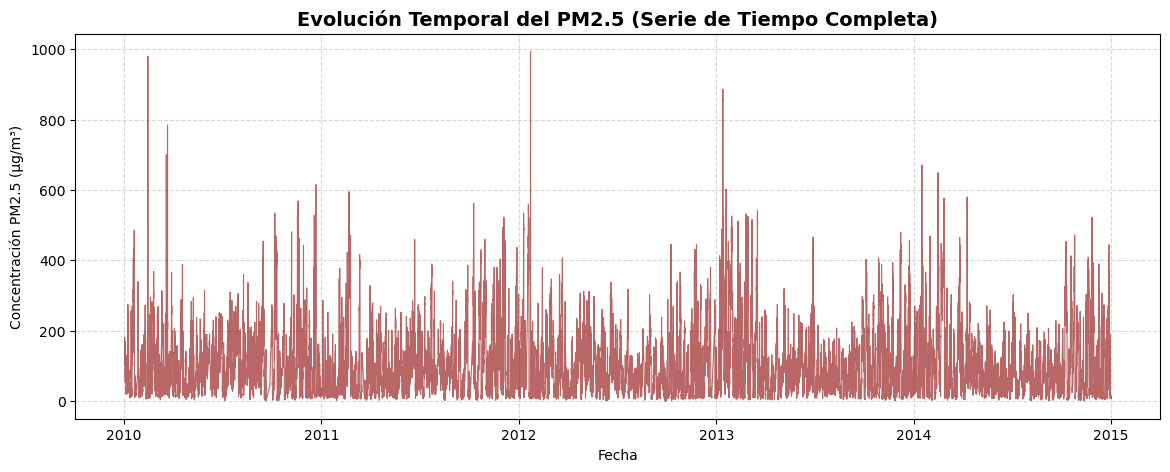

In [14]:

plt.figure(figsize=(14, 5))
plt.plot(data_clean.index, data_clean['pm2.5'], color='darkred', alpha=0.6, linewidth=0.8)
plt.title('Evolución Temporal del PM2.5 (Serie de Tiempo Completa)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Concentración PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

En la grafica de evolución temporal del $PM_{2.5}$ durante los 5 años, se observa que casi siempre a inicio y final de año es donde se observan valores elevados de contaminación. Mientras que para los meses de mitad de año, los valores de contaminación son más bajos.

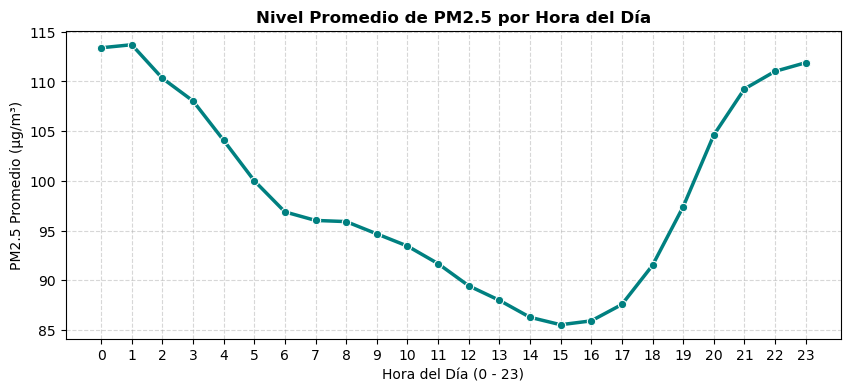

In [21]:
# Grafica nivel promedio pm2.5 por hora del dia

# Agrupo los datos por hora del dia
prom_hour = data_clean.groupby(data_clean.index.hour)['pm2.5'].mean().reset_index()

prom_hour.columns = ['hour', 'pm2.5']

plt.figure(figsize=(10, 4))
sns.lineplot(data=prom_hour, x='hour', y='pm2.5', marker='o', color='teal', linewidth=2.5)

plt.title('Nivel Promedio de PM2.5 por Hora del Día', fontsize=12, fontweight='bold')
plt.xlabel('Hora del Día (0 - 23)')
plt.ylabel('PM2.5 Promedio (µg/m³)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

La concentración promedio de $PM_{2.5}$ presenta una marcada variabilidad diurna con un patrón especifico. Las concentraciones más críticas de contaminación se concentran en el rango de la noche y madrugada (20:00 - 01:00 hrs) debido a condiciones meteorológicas desfavorables para la dispersión. Por el contrario, la tarde (14:00 - 16:00 hrs) representa el período con aire más limpio, quizás por el incremento en la la radiación solar.